In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# choose which one you want to use/ customize this section for your own file system.

# url = "https://drive.google.com/file/d/1-T4dkpwBNuxPtKu3yvEcs8RPVoOX2Gkv/view?usp=sharing"
# url = 'https://drive.google.com/uc?id=' + url.split('/')[-2]
# imdb = pd.read_csv(url)

imdb = pd.read_csv("movie-data/Imdb_Movie_Dataset.csv")

In [3]:
print(imdb.head(25).to_string())

        id                                              title  vote_average  vote_count    status release_date     revenue  runtime  adult     budget    imdb_id original_language                                     original_title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    overview  popularity                                                                                 tagline                                       genres                                                                                                                 production_companies 

In [4]:
# Counting the number of rows in the dataset.
# .shape[0] gives the number of rows and [1] is columns.

num_observations = imdb.shape[0]
print(num_observations)

1048575


In [5]:
# Checks how many values in each column are unique.

unique_column_values = imdb.nunique(0)

print(unique_column_values)

id                      1047781
title                    903262
vote_average               5024
vote_count                 3598
status                        6
release_date              42375
revenue                   14242
runtime                     741
adult                         2
budget                     5586
imdb_id                  559319
original_language           172
original_title           933950
overview                 808624
popularity                19833
tagline                  146892
genres                    13117
production_companies     197343
production_countries       9723
spoken_languages           6839
keywords                 170704
dtype: int64


In [6]:
# Sorting the dataset by ID because the ID has the least number of duplicates.
srt_ID_df = imdb.copy()
srt_ID_df = srt_ID_df.sort_values(by="id", ascending=True)

print(srt_ID_df.head(25).to_string())

       id                                                   title  vote_average  vote_count    status release_date    revenue  runtime  adult     budget    imdb_id original_language                                          original_title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [7]:
# This shows all the entries which are duplicates.
duplicate_IDs = srt_ID_df[srt_ID_df.duplicated(subset=['id'], keep=False)]
print(duplicate_IDs)


             id                           title  vote_average  vote_count  \
722297  1192939  Soldiers from Eastern Europe 6           0.0           0   
722298  1192939  Soldiers from Eastern Europe 6           0.0           0   
722299  1192939  Soldiers from Eastern Europe 6           0.0           0   
722300  1192939  Soldiers from Eastern Europe 6           0.0           0   
722302  1192940                              杀夫           0.0           0   
...         ...                             ...           ...         ...   
459954  1409643     Abel Ernest Tembo's Suspect           0.0           0   
467911  1410107   Older Women & Younger Women 5           0.0           0   
467892  1410107   Older Women & Younger Women 5           0.0           0   
465794  1410516                     Yegna Neger           0.0           0   
467456  1410516                     Yegna Neger           0.0           0   

               status release_date  revenue  runtime  adult  budget  ...  \

In [8]:
# We should combine the duplicates into one entry for each duplicate.

In [9]:
# This lists how many missing values exist for each column.
missing_values_in_columns = srt_ID_df.isna().sum()
print(missing_values_in_columns)

id                           0
title                       13
vote_average                 0
vote_count                   0
status                       0
release_date            181817
revenue                      0
runtime                      0
adult                        0
budget                       0
imdb_id                 488003
original_language            0
original_title              13
overview                215824
popularity                   0
tagline                 895847
genres                  414972
production_companies    568428
production_countries    463497
spoken_languages        440662
keywords                755954
dtype: int64


In [10]:
# We need to figure out what to do about these missing values!

In [11]:
# Removing columns that are more than 50% empty.

column_names_list = srt_ID_df.columns.tolist()
print(column_names_list)

num_columns = srt_ID_df.shape[0]
fifty_pcnt = int(num_columns / 2)
dropped_missing_df = srt_ID_df.copy()

for column, mssng_count in missing_values_in_columns.items():
    if mssng_count > fifty_pcnt:
        print(f"Removed Column: {column}\n    Missing Count: {mssng_count}")
        dropped_missing_df = dropped_missing_df.drop(column, axis=1)

column_names_list = dropped_missing_df.columns.tolist()
print(column_names_list)

['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'budget', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']
Removed Column: tagline
    Missing Count: 895847
Removed Column: production_companies
    Missing Count: 568428
Removed Column: keywords
    Missing Count: 755954
['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'budget', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'genres', 'production_countries', 'spoken_languages']


In [12]:
missing_values_in_columns = dropped_missing_df.isna().sum()
print(missing_values_in_columns)

id                           0
title                       13
vote_average                 0
vote_count                   0
status                       0
release_date            181817
revenue                      0
runtime                      0
adult                        0
budget                       0
imdb_id                 488003
original_language            0
original_title              13
overview                215824
popularity                   0
genres                  414972
production_countries    463497
spoken_languages        440662
dtype: int64


In [13]:
# Checking the column datatypes.
# This will help us determine Numerical, Categorical, Binary, etc. for the data.
column_types = dropped_missing_df.dtypes
print(column_types)


id                        int64
title                    object
vote_average            float64
vote_count                int64
status                   object
release_date             object
revenue                   int64
runtime                   int64
adult                      bool
budget                    int64
imdb_id                  object
original_language        object
original_title           object
overview                 object
popularity              float64
genres                   object
production_countries     object
spoken_languages         object
dtype: object


In [14]:
unique_column_values = dropped_missing_df.nunique(0)
print(unique_column_values)

id                      1047781
title                    903262
vote_average               5024
vote_count                 3598
status                        6
release_date              42375
revenue                   14242
runtime                     741
adult                         2
budget                     5586
imdb_id                  559319
original_language           172
original_title           933950
overview                 808624
popularity                19833
genres                    13117
production_countries       9723
spoken_languages           6839
dtype: int64


In [15]:
numerical_columns = ["id", "vote_average", "vote_count", "revenue", "runtime", "budget", "popularity"]
categorical_columns = ["original_language", "genres", "production_countries", "spoken_languages"]
binary_columns = ["status", "adult"]
ordinal_columns = [""]
text_columns = ["text", "release_date", "original_title", "overview"]
# Left out: imdb_id


In [18]:
status_unique_values = dropped_missing_df["status"].unique()
print(status_unique_values)


['Released' 'Post Production' 'Rumored' 'Canceled' 'Planned'
 'In Production']


In [ ]:
# the binary column Adult is converted to 0 = False and 1 = True.
converted_adult_df = dropped_missing_df.copy()

converted_adult_df["adult"] = converted_adult_df["adult"].astype(int)

print(converted_adult_df["adult"])


9847      0
9368      0
1819      0
8939      0
42892     0
         ..
466709    0
466653    0
464765    1
465881    0
466536    1
Name: adult, Length: 1048575, dtype: int32


In [20]:
# Think of doing one-hot OR Ordinal encoding for the Status column.

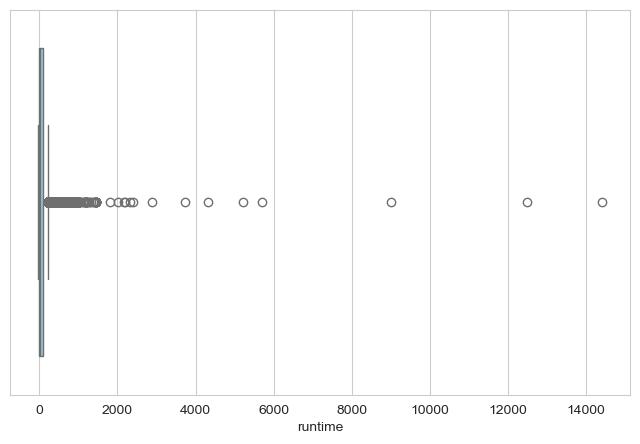

In [ ]:
# Runtime data

cleaned_df = converted_adult_df.copy()





plt.figure(figsize=(8,5))
sns.set_style("whitegrid")
sns.boxplot(x=cleaned_df["runtime"], color="skyblue")
plt.show()
